In [0]:
flights_data = [
("F101","Indigo","Hyderabad","Delhi",140,"On Time"),
("F102","Air India","Mumbai","Chennai",120,"Delayed"),
("F103","Vistara","Bangalore","Hyderabad",90,"On Time"),
("F104","Indigo","Delhi","Mumbai",130,"Cancelled"),
("F105","Air India","Chennai","Bangalore",80,"On Time"),
("F106","Akasa","Pune","Delhi",150,"Delayed"),
("F107","Vistara","Hyderabad","Kolkata",160,"On Time"),
("F108","Indigo","Mumbai","Hyderabad",110,"On Time"),
("F109","Akasa","Delhi","Chennai",145,"Delayed"),
("F110","Air India","Bangalore","Mumbai",95,"On Time"),
("F111","Indigo","Hyderabad","Goa",75,"On Time"),
("F112","Vistara","Goa","Delhi",150,"Cancelled"),
("F113","Akasa","Chennai","Pune",100,"On Time"),
("F114","Air India","Kolkata","Bangalore",170,"Delayed"),
("F115","Indigo","Delhi","Hyderabad",135,"On Time")
]

flight_columns = [
    "flight_id",
    "airline",
    "from_city",
    "to_city",
    "duration",
    "status"
]

df_flights = spark.createDataFrame(
    flights_data,
    flight_columns
)

In [0]:
bookings_data = [
("B1001","F101","Rahul Sharma","Economy",8500,"2026-06-01"),
("B1002","F101","Priya Reddy","Business",22000,"2026-06-01"),
("B1003","F102","Amit Kumar","Economy",9000,"2026-06-02"),
("B1004","F103","Sneha Patel","Premium Economy",15000,"2026-06-02"),
("B1005","F104","Farhan Ali","Economy",7500,"2026-06-03"),
("B1006","F105","Neha Singh","Business",25000,"2026-06-03"),
("B1007","F106","Arjun Verma","Economy",10000,"2026-06-04"),
("B1008","F107","Meera Nair","Premium Economy",17000,"2026-06-04"),
("B1009","F108","Kiran Rao","Economy",9500,"2026-06-05"),
("B1010","F109","Nisha Reddy","Business",28000,"2026-06-05"),
("B1011","F110","David Thomas","Economy",8000,"2026-06-06"),
("B1012","F111","Ayesha Khan","Premium Economy",16000,"2026-06-06"),
("B1013","F112","Rohit Sharma","Economy",7000,"2026-06-07"),
("B1014","F113","Pooja Mehta","Business",24000,"2026-06-07"),
("B1015","F114","Sanjay Gupta","Economy",10500,"2026-06-08"),
("B1016","F115","Divya Iyer","Premium Economy",18000,"2026-06-08"),
("B1017","F101","Vikram Singh","Economy",8500,"2026-06-09"),
("B1018","F103","Anjali Rao","Business",23000,"2026-06-09"),
("B1019","F107","Faiz Ahmed","Economy",9500,"2026-06-10"),
("B1020","F110","Megha Kapoor","Premium Economy",15500,"2026-06-10")
]

booking_columns = [
    "booking_id",
    "flight_id",
    "passenger_name",
    "travel_class",
    "ticket_price",
    "booking_date"
]

df_bookings = spark.createDataFrame(
    bookings_data,
    booking_columns
)

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

flights_pd = df_flights.toPandas()
bookings_pd = df_bookings.toPandas()


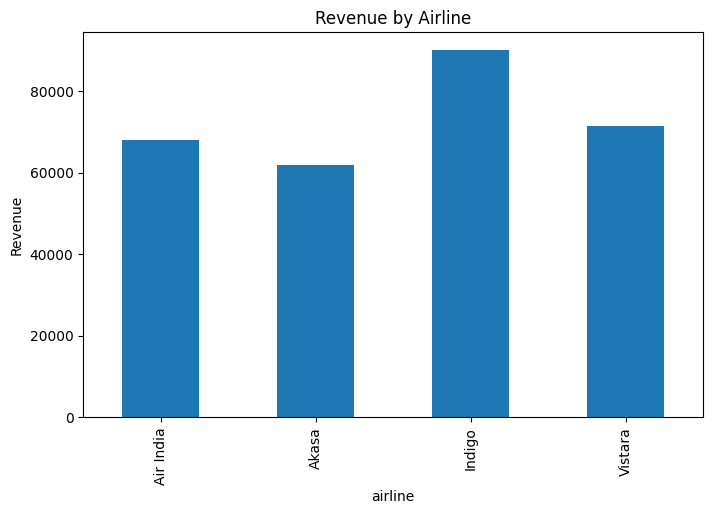

In [0]:
merged = bookings_pd.merge(
    flights_pd,
    on="flight_id"
)

revenue_airline = merged.groupby(
    "airline"
)["ticket_price"].sum()

revenue_airline.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Airline")
plt.ylabel("Revenue")
plt.show()

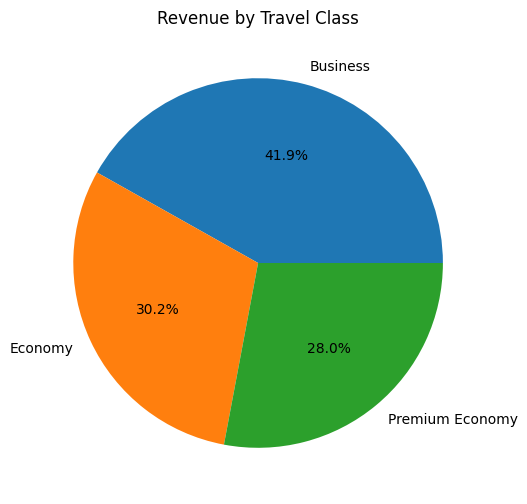

In [0]:
travel_class_rev = bookings_pd.groupby(
    "travel_class"
)["ticket_price"].sum()

travel_class_rev.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Revenue by Travel Class")
plt.ylabel("")
plt.show()

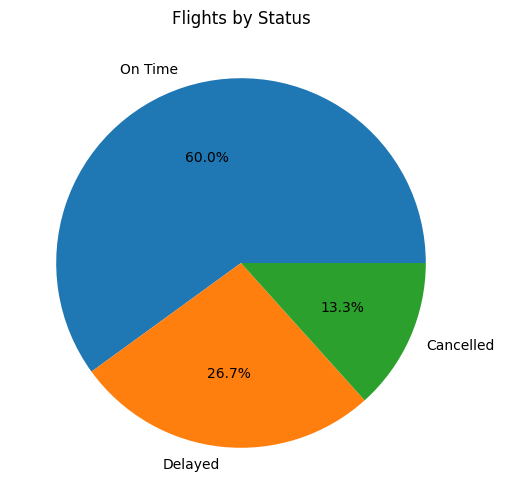

In [0]:
flights_pd["status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Flights by Status")
plt.ylabel("")
plt.show()

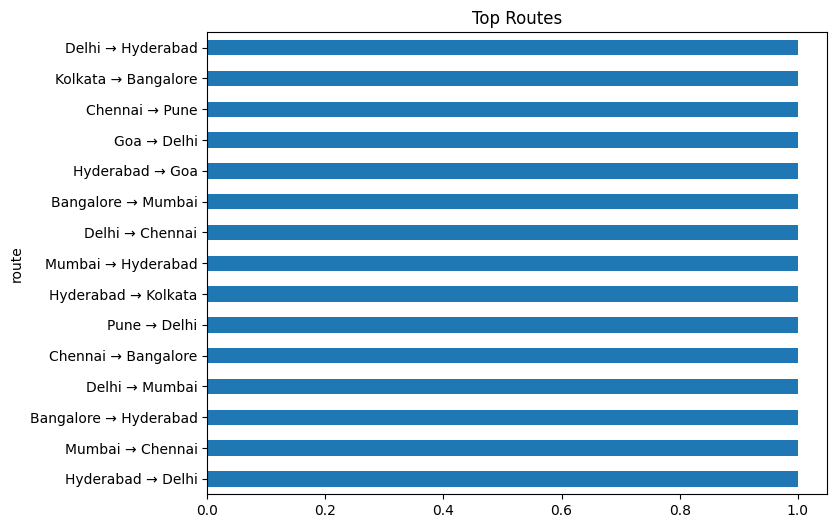

In [0]:
flights_pd["route"] = (
    flights_pd["from_city"]
    + " → "
    + flights_pd["to_city"]
)

flights_pd["route"].value_counts().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top Routes")
plt.show()

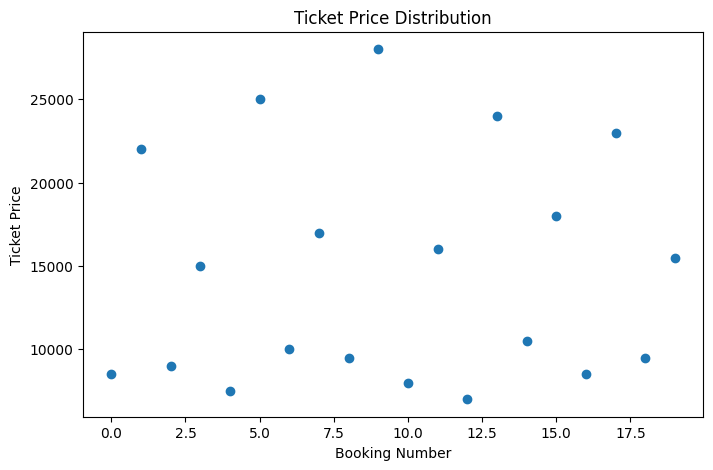

In [0]:
plt.figure(figsize=(8,5))

plt.scatter(
    bookings_pd.index,
    bookings_pd["ticket_price"]
)

plt.title("Ticket Price Distribution")
plt.xlabel("Booking Number")
plt.ylabel("Ticket Price")

plt.show()